# 16 - ML Approach changes and additions from Gemma's feedback

Multiple models, ROC curves with threshold selection, leave-one-out CV, Boruta feature selection, and hyperparameter search.

Addresses Gemma's recommendations from 27 Apr meeting. Runs on the existing 134-study dataset with ~31 features after correlation removal.

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]
y_full = df["rejection"].values

print(f"Total samples: {len(df)}")
print(f"Features: {len(feature_cols)}")
print(f"Class balance: {sum(y_full == 0)} no-rejection, {sum(y_full == 1)} rejection")

Total samples: 134
Features: 93
Class balance: 95 no-rejection, 39 rejection


In [2]:
# Remove highly correlated features, keeping the one with lower p-value
stats_path = os.path.join("reports", "14a_stats_radiomics_features.csv")
p_values = {}
if os.path.exists(stats_path):
    stats_df = pd.read_csv(stats_path)
    p_values = dict(zip(stats_df["feature"], stats_df["p_value"]))

corr = df[feature_cols].corr().abs()
to_drop = set()
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            fi = feature_cols[i]
            fj = feature_cols[j]
            if fi in to_drop or fj in to_drop:
                continue
            if p_values.get(fi, 1.0) <= p_values.get(fj, 1.0):
                to_drop.add(fj)
            else:
                to_drop.add(fi)

reduced_features = [f for f in feature_cols if f not in to_drop]
X_full = df[reduced_features].values

print(f"Removed {len(to_drop)} correlated features")
print(f"Remaining: {len(reduced_features)} features")

Removed 62 correlated features
Remaining: 31 features


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, stratify=y_full, random_state=42
)

print(f"Train: {len(X_train)} samples ({sum(y_train == 0)} no-rej, {sum(y_train == 1)} rej)")
print(f"Test:  {len(X_test)} samples ({sum(y_test == 0)} no-rej, {sum(y_test == 1)} rej)")

Train: 93 samples (66 no-rej, 27 rej)
Test:  41 samples (29 no-rej, 12 rej)


## Baseline models — single train/test split

Train 4 models on all features with one split. This is the simplest evaluation.

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

models = {
    "LogReg": LogisticRegression(C=1.0, penalty="l2", class_weight="balanced",
                                  max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                  class_weight="balanced", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "NaiveBayes": GaussianNB(),
}

baseline_results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    train_proba = model.predict_proba(X_train_sc)[:, 1]
    test_proba = model.predict_proba(X_test_sc)[:, 1]
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    baseline_results[name] = {
        "train_auc": train_auc,
        "test_auc": test_auc,
        "test_proba": test_proba,
    }
    print(f"{name:12s}  train AUC = {train_auc:.3f}  test AUC = {test_auc:.3f}")

LogReg        train AUC = 0.793  test AUC = 0.477
RF            train AUC = 0.995  test AUC = 0.517
SVM           train AUC = 0.097  test AUC = 0.486
NaiveBayes    train AUC = 0.673  test AUC = 0.589


## ROC curves and threshold selection

All models above use a default threshold of 0.5 to convert probabilities into class predictions. But this is arbitrary — a different threshold gives different sensitivity and specificity.

The ROC curve shows performance at every possible threshold. **Youden's index** (J = sensitivity + specificity - 1) picks the threshold that maximizes the combined trade-off. This answers Gemma's question: "how do you choose that threshold?"

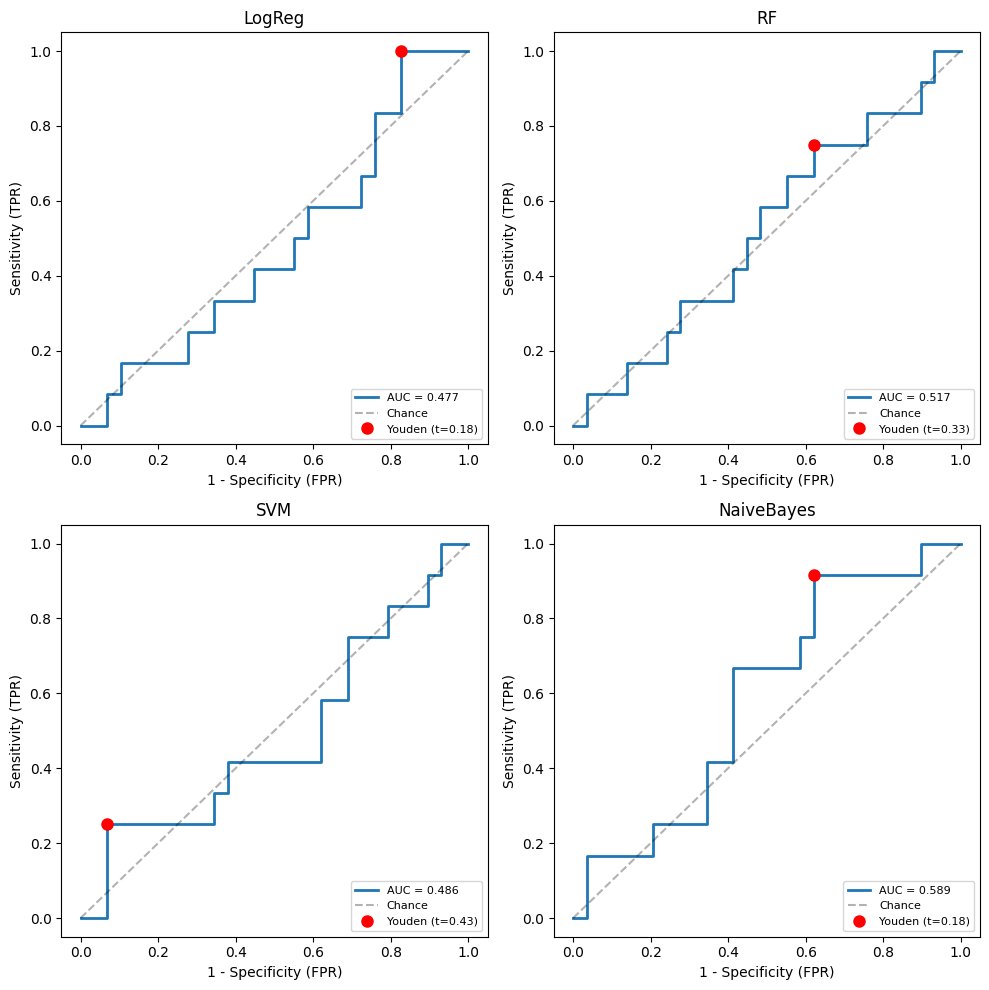


Youden threshold summary (single split):
  LogReg        AUC=0.477  thresh=0.181  sens=1.000  spec=0.172
  RF            AUC=0.517  thresh=0.331  sens=0.750  spec=0.379
  SVM           AUC=0.486  thresh=0.426  sens=0.250  spec=0.931
  NaiveBayes    AUC=0.589  thresh=0.177  sens=0.917  spec=0.379


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

youden_table = []

for idx, (name, res) in enumerate(baseline_results.items()):
    ax = axes[idx]
    fpr, tpr, thresholds = roc_curve(y_test, res["test_proba"])
    auc_val = res["test_auc"]

    # Youden's index
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]
    best_sens = tpr[best_idx]
    best_spec = 1 - fpr[best_idx]

    # Plot
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
    ax.plot(fpr[best_idx], tpr[best_idx], "ro", markersize=8,
            label=f"Youden (t={best_thresh:.2f})")
    ax.set_xlabel("1 - Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title(name)
    ax.legend(loc="lower right", fontsize=8)

    youden_table.append({
        "model": name, "AUC": round(auc_val, 3),
        "threshold": round(best_thresh, 3),
        "sensitivity": round(best_sens, 3),
        "specificity": round(best_spec, 3),
    })

plt.tight_layout()
plt.savefig(os.path.join("reports", "16_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nYouden threshold summary (single split):")
for row in youden_table:
    print(f"  {row['model']:12s}  AUC={row['AUC']:.3f}  "
          f"thresh={row['threshold']:.3f}  "
          f"sens={row['sensitivity']:.3f}  spec={row['specificity']:.3f}")

If a model's ROC curve hugs the diagonal, it is no better than random guessing. The Youden threshold is the "best case" for that model — if sensitivity and specificity are both low even at the optimal threshold, the model has no real discriminative power.

## Leave-one-out cross-validation

A single train/test split can be lucky or unlucky. With 134 samples, LOOCV is more robust: train on 133, test on 1, repeat 134 times. Every sample gets exactly one turn as the test sample. We also scale inside each fold to avoid data leakage.

In [6]:
loo = LeaveOneOut()

model_defs = {
    "LogReg": lambda: LogisticRegression(C=1.0, penalty="l2", class_weight="balanced",
                                          max_iter=1000, random_state=42),
    "RF": lambda: RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5,
                                          class_weight="balanced", random_state=42),
    "SVM": lambda: SVC(kernel="rbf", probability=True, class_weight="balanced",
                        random_state=42),
    "NaiveBayes": lambda: GaussianNB(),
}

loocv_probas = {}

for name, make_model in model_defs.items():
    y_pred_proba = np.zeros(len(X_full))

    for train_idx, test_idx in loo.split(X_full):
        X_tr, X_te = X_full[train_idx], X_full[test_idx]
        y_tr = y_full[train_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        model = make_model()
        model.fit(X_tr_sc, y_tr)
        y_pred_proba[test_idx] = model.predict_proba(X_te_sc)[:, 1]

    auc_val = roc_auc_score(y_full, y_pred_proba)
    loocv_probas[name] = y_pred_proba
    print(f"{name:12s}  LOOCV AUC = {auc_val:.3f}")

LogReg        LOOCV AUC = 0.478
RF            LOOCV AUC = 0.437
SVM           LOOCV AUC = 0.409
NaiveBayes    LOOCV AUC = 0.500


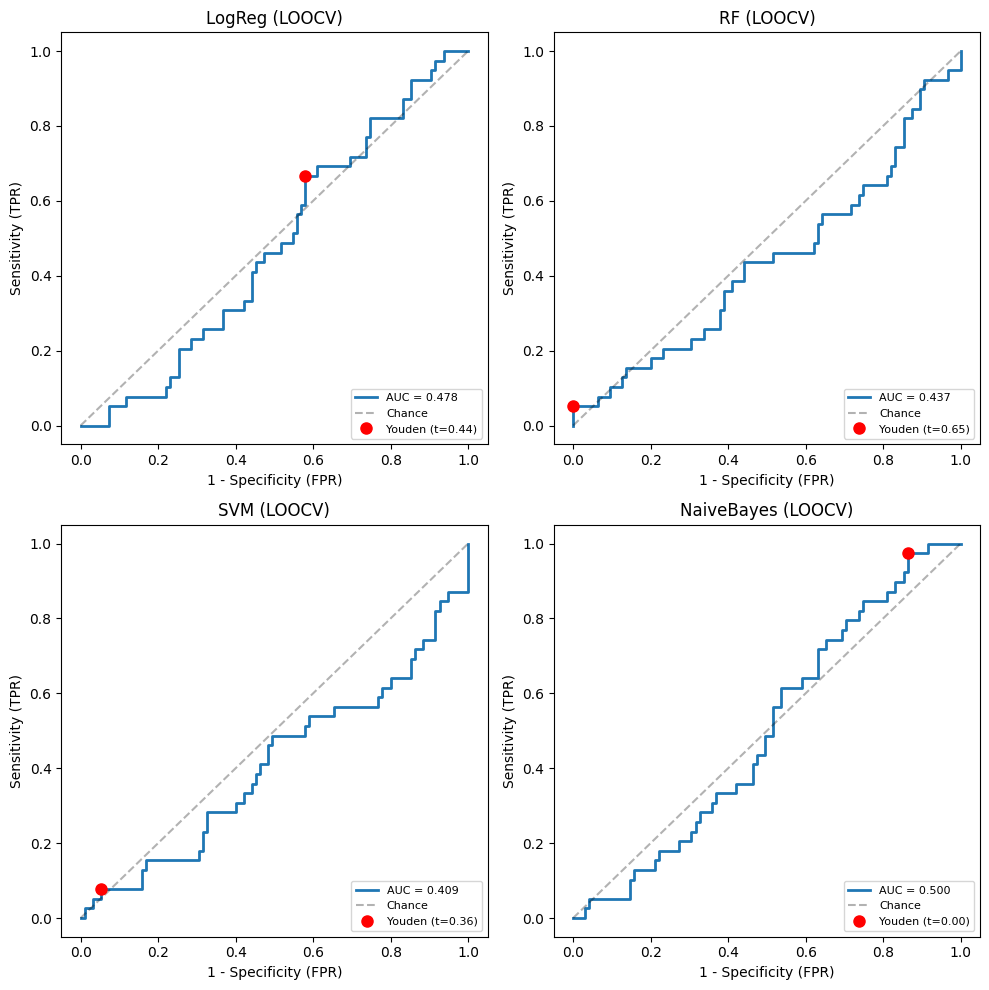


Youden threshold summary (LOOCV):
  LogReg        AUC=0.478  thresh=0.436  sens=0.667  spec=0.421
  RF            AUC=0.437  thresh=0.653  sens=0.051  spec=1.000
  SVM           AUC=0.409  thresh=0.355  sens=0.077  spec=0.947
  NaiveBayes    AUC=0.500  thresh=0.000  sens=0.974  spec=0.137


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

loocv_youden = []

for idx, (name, y_proba) in enumerate(loocv_probas.items()):
    ax = axes[idx]
    fpr, tpr, thresholds = roc_curve(y_full, y_proba)
    auc_val = roc_auc_score(y_full, y_proba)

    J = tpr - fpr
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]
    best_sens = tpr[best_idx]
    best_spec = 1 - fpr[best_idx]

    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
    ax.plot(fpr[best_idx], tpr[best_idx], "ro", markersize=8,
            label=f"Youden (t={best_thresh:.2f})")
    ax.set_xlabel("1 - Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title(f"{name} (LOOCV)")
    ax.legend(loc="lower right", fontsize=8)

    loocv_youden.append({
        "model": name, "AUC": round(auc_val, 3),
        "threshold": round(best_thresh, 3),
        "sensitivity": round(best_sens, 3),
        "specificity": round(best_spec, 3),
    })

plt.tight_layout()
plt.savefig(os.path.join("reports", "16_roc_curves_loocv.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nYouden threshold summary (LOOCV):")
for row in loocv_youden:
    print(f"  {row['model']:12s}  AUC={row['AUC']:.3f}  "
          f"thresh={row['threshold']:.3f}  "
          f"sens={row['sensitivity']:.3f}  spec={row['specificity']:.3f}")

### LOOCV vs single split

Compare the AUCs above with the single-split results. If they are similar, the single split was representative. If they differ a lot, the single split was misleading.

## Boruta feature selection

Boruta creates "shadow" copies of all features (shuffled versions that carry no real information), trains a Random Forest, and checks which real features consistently outperform their shadows. Features that never beat shadows are rejected.

Reference: Kursa & Rudnicki (2010), "Feature Selection with the Boruta Package", Journal of Statistical Software 36(11).

In [8]:
from boruta import BorutaPy

scaler_boruta = StandardScaler()
X_scaled = scaler_boruta.fit_transform(X_full)

rf_boruta = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=5,
    class_weight="balanced", random_state=42
)

boruta = BorutaPy(
    estimator=rf_boruta,
    n_estimators="auto",
    max_iter=200,
    random_state=42,
    verbose=0,
)
boruta.fit(X_scaled, y_full)

confirmed = [f for f, s in zip(reduced_features, boruta.support_) if s]
tentative = [f for f, s in zip(reduced_features, boruta.support_weak_) if s]
rejected = [f for f, sup, weak in zip(reduced_features, boruta.support_, boruta.support_weak_)
            if not sup and not weak]

print(f"Confirmed features ({len(confirmed)}): {confirmed}")
print(f"Tentative features ({len(tentative)}): {tentative}")
print(f"Rejected features ({len(rejected)}): {rejected}")

if len(confirmed) == 0 and len(tentative) == 0:
    print("\nBoruta found no features consistently better than random noise.")

Confirmed features (0): []
Tentative features (0): []
Rejected features (31): ['original_firstorder_Energy', 'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_Minimum', 'original_firstorder_Range', 'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency', 'original_glcm_Idmn', 'original_glcm_Idn', 'original_glcm_Imc2', 'original_glcm_JointAverage', 'original_glcm_JointEnergy', 'original_glcm_MCC', 'original_glcm_MaximumProbability', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_glrlm_LongRunLowGrayLevelEmphasis', 'original_glrlm_LowGrayLevelRunEmphasis', 'original_glrlm_RunEntropy', 'original_glrlm_RunLengthNonUniformity', 'original_glrlm_RunLengthNonUniformityNormalized', 'original_glrlm_ShortRunEmphasis', 'original_glrlm_ShortRunHighGrayLevelEmphasis', 'original_glrlm_ShortRunLowGrayLevelEmphasis', 'original_gldm_DependenceNonUniformity', 'original_ngtdm_Busyness',

In [9]:
# Re-evaluate with Boruta-selected features (confirmed + tentative)
boruta_features = confirmed + tentative

if len(boruta_features) > 0:
    boruta_idx = [reduced_features.index(f) for f in boruta_features]
    X_boruta = X_full[:, boruta_idx]

    print(f"Re-running LOOCV with {len(boruta_features)} Boruta features...")
    for name, make_model in model_defs.items():
        y_pred_proba = np.zeros(len(X_boruta))
        for train_idx, test_idx in loo.split(X_boruta):
            X_tr, X_te = X_boruta[train_idx], X_boruta[test_idx]
            y_tr = y_full[train_idx]
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_te_sc = scaler.transform(X_te)
            model = make_model()
            model.fit(X_tr_sc, y_tr)
            y_pred_proba[test_idx] = model.predict_proba(X_te_sc)[:, 1]
        auc_val = roc_auc_score(y_full, y_pred_proba)
        print(f"  {name:12s}  LOOCV AUC (Boruta) = {auc_val:.3f}")
else:
    print("No Boruta features selected — skipping re-evaluation.")

No Boruta features selected — skipping re-evaluation.


## Hyperparameter optimization

Even with default hyperparameters showing weak results, we should check whether different settings help. Grid search tries all combinations and picks the best via LOOCV.

In [10]:
param_grids = {
    "LogReg": {
        "model": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1.0, 10.0],
            "penalty": ["l1", "l2"],
            "solver": ["saga"],
        },
    },
    "SVM": {
        "model": SVC(probability=True, class_weight="balanced", random_state=42),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ["linear", "rbf"],
        },
    },
    "RF": {
        "model": RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                         random_state=42),
        "params": {
            "max_depth": [3, 5, 7],
            "min_samples_leaf": [3, 5, 10],
        },
    },
    "NaiveBayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-9, 1e-7, 1e-5],
        },
    },
}

scaler_gs = StandardScaler()
X_gs = scaler_gs.fit_transform(X_full)

print("Grid search with LOOCV (this may take a minute)...\n")
gridsearch_results = {}
for name, spec in param_grids.items():
    gs = GridSearchCV(
        estimator=spec["model"],
        param_grid=spec["params"],
        cv=LeaveOneOut(),
        scoring="roc_auc",
        n_jobs=-1,
    )
    gs.fit(X_gs, y_full)
    gridsearch_results[name] = {
        "best_params": gs.best_params_,
        "best_auc": gs.best_score_,
    }
    print(f"{name:12s}  best LOOCV AUC = {gs.best_score_:.3f}")
    print(f"{'':12s}  best params: {gs.best_params_}")
    print()

Grid search with LOOCV (this may take a minute)...



/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/li

LogReg        best LOOCV AUC = nan
              best params: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}



b/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:37

SVM           best LOOCV AUC = nan
              best params: {'C': 0.1, 'kernel': 'linear'}



/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/li

RF            best LOOCV AUC = nan
              best params: {'max_depth': 3, 'min_samples_leaf': 3}

NaiveBayes    best LOOCV AUC = nan
              best params: {'var_smoothing': 1e-09}



/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/thesis_env/li

In [11]:
rows = []

# Single split results
for name, res in baseline_results.items():
    rows.append({
        "model": name, "evaluation": "single_split",
        "feature_set": "all", "AUC": round(res["test_auc"], 3),
    })

# LOOCV results
for row in loocv_youden:
    rows.append({
        "model": row["model"], "evaluation": "LOOCV",
        "feature_set": "all", "AUC": row["AUC"],
        "sensitivity": row["sensitivity"], "specificity": row["specificity"],
        "threshold": row["threshold"],
    })

# Grid search results
for name, res in gridsearch_results.items():
    rows.append({
        "model": name, "evaluation": "LOOCV_gridsearch",
        "feature_set": "all", "AUC": round(res["best_auc"], 3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join("reports", "16_comprehensive_ml_results.csv"), index=False)
print("\nSaved to reports/16_comprehensive_ml_results.csv")

     model       evaluation feature_set   AUC  sensitivity  specificity  threshold
    LogReg     single_split         all 0.477          NaN          NaN        NaN
        RF     single_split         all 0.517          NaN          NaN        NaN
       SVM     single_split         all 0.486          NaN          NaN        NaN
NaiveBayes     single_split         all 0.589          NaN          NaN        NaN
    LogReg            LOOCV         all 0.478        0.667        0.421      0.436
        RF            LOOCV         all 0.437        0.051        1.000      0.653
       SVM            LOOCV         all 0.409        0.077        0.947      0.355
NaiveBayes            LOOCV         all 0.500        0.974        0.137      0.000
    LogReg LOOCV_gridsearch         all   NaN          NaN          NaN        NaN
       SVM LOOCV_gridsearch         all   NaN          NaN          NaN        NaN
        RF LOOCV_gridsearch         all   NaN          NaN          NaN        NaN
Naiv

## Interpretation

(To be written after seeing results.)

Key questions:
- Do any models beat chance (AUC > 0.5) consistently across both single-split and LOOCV?
- Does Boruta confirm or reject all features?
- Does hyperparameter tuning improve any model beyond chance?
- If nothing works: radiomics texture features from B-mode ultrasound do not predict pancreas transplant rejection in this cohort, regardless of model choice, threshold, feature selection, or hyperparameters.

## Late subset (motivo 3, 4, 5)

The late subset has 68 samples with better class balance (39 no-rejection, 29 rejection). Repeating LOOCV here to check if signal is stronger in late post-transplant studies.

Late subset: 68 samples (39 no-rej, 29 rej)
LogReg        LOOCV AUC = 0.503  sens=0.621  spec=0.590
RF            LOOCV AUC = 0.409  sens=0.241  spec=0.846
SVM           LOOCV AUC = 0.141  sens=0.000  spec=1.000
NaiveBayes    LOOCV AUC = 0.496  sens=0.138  spec=1.000


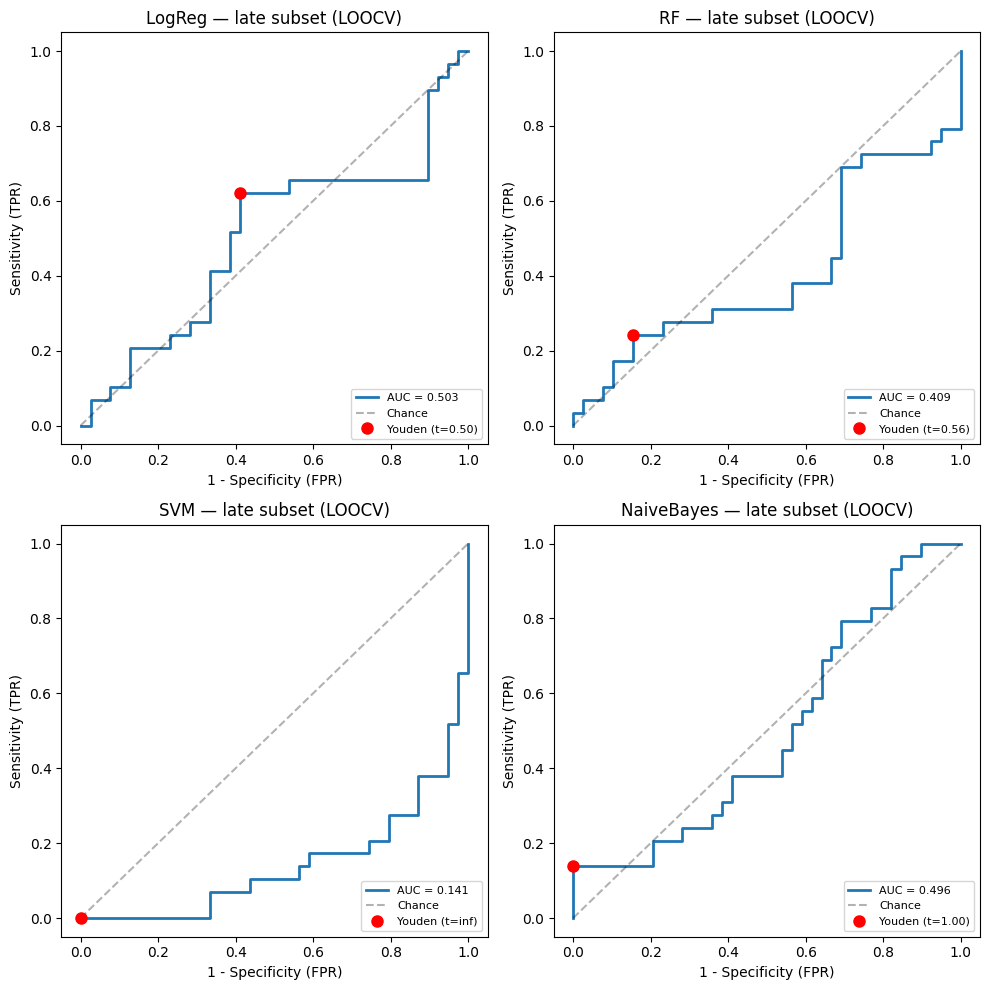

In [12]:
late_mask = df["motivo"].isin([3, 4, 5])
X_late = df.loc[late_mask, reduced_features].values
y_late = df.loc[late_mask, "rejection"].values

print(f"Late subset: {len(X_late)} samples ({sum(y_late == 0)} no-rej, {sum(y_late == 1)} rej)")

loo_late = LeaveOneOut()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
late_youden = []

for idx, (name, make_model) in enumerate(model_defs.items()):
    y_pred_proba = np.zeros(len(X_late))
    for train_idx, test_idx in loo_late.split(X_late):
        X_tr, X_te = X_late[train_idx], X_late[test_idx]
        y_tr = y_late[train_idx]
        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)
        model = make_model()
        model.fit(X_tr_sc, y_tr)
        y_pred_proba[test_idx] = model.predict_proba(X_te_sc)[:, 1]

    auc_val = roc_auc_score(y_late, y_pred_proba)

    ax = axes[idx]
    fpr, tpr, thresholds = roc_curve(y_late, y_pred_proba)
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_thresh = thresholds[best_idx]
    best_sens = tpr[best_idx]
    best_spec = 1 - fpr[best_idx]

    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_val:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
    ax.plot(fpr[best_idx], tpr[best_idx], "ro", markersize=8,
            label=f"Youden (t={best_thresh:.2f})")
    ax.set_xlabel("1 - Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title(f"{name} — late subset (LOOCV)")
    ax.legend(loc="lower right", fontsize=8)

    late_youden.append({
        "model": name, "AUC": round(auc_val, 3),
        "threshold": round(best_thresh, 3),
        "sensitivity": round(best_sens, 3),
        "specificity": round(best_spec, 3),
    })
    print(f"{name:12s}  LOOCV AUC = {auc_val:.3f}  "
          f"sens={best_sens:.3f}  spec={best_spec:.3f}")

plt.tight_layout()
plt.savefig(os.path.join("reports", "16_roc_curves_loocv_late.png"),
            dpi=150, bbox_inches="tight")
plt.show()